In [26]:
#Importando as bibliotecas

import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import linregress


## 1. Carregamento e limpeza dos dados
A planilha é lida com `pd.read_excel` a partir da pasta `refs/`. Em seguida, `dropna()` remove linhas com valores ausentes, para que nenhuma observação incompleta entre nos cálculos. A base não tinha valores ausentes: permanecem **1.000 linhas e 3 colunas**.

In [27]:
#Definindo a variável "arquivo" pelo nome da planilha.
arquivo='Eficiencia Operacional em Linhas de Producao.xlsx'

df=pd.read_excel(arquivo)

#Vizualindo as 5 primeiras observações do dataframe df
df.head()

df=df.dropna()

df

,Nivel_Automacao,Tempo_Ciclo_s,Unidades_Produzidas
0,Alta,52.42,523
1,Baixa,43.03,643
2,Média,58.33,421
3,Baixa,55.95,495
4,Alta,36.54,832
...,...,...,...
995,Baixa,54.31,446
996,Média,49.62,601
997,Alta,51.04,597
998,Média,57.56,400


## 2. Variável independente (x) e variável dependente (y)
- **x = `Tempo_Ciclo_s`** (variável explicativa): tempo, em segundos, que a linha leva para completar um ciclo.
- **y = `Unidades_Produzidas`** (variável resposta): quantidade produzida.

**Justificativa:** quanto mais longo o ciclo, menos ciclos cabem no período e, em tese, menos unidades são produzidas. Faz sentido, portanto, tratar a produção como dependente do tempo de ciclo. Os 1.000 pares (x, y) estão completos.

In [28]:
#Definindo a variável independente x e a variável dependente y
x=df.Tempo_Ciclo_s
y=df.Unidades_Produzidas
n = len(df)
pd.DataFrame({"Variável": ["Tempo_Ciclo_s (x)", "Unidades_Produzidas (Y)"], "Observações": [x.count(), y.count()]})

,Variável,Observações
0,Tempo_Ciclo_s (x),1000
1,Unidades_Produzidas (Y),1000


## Correlação linear
**Objetivo:** verificar se o tempo de ciclo (`Tempo_Ciclo_s`) está associado à quantidade de unidades produzidas (`Unidades_Produzidas`) e medir a intensidade dessa associação. Espera-se que ciclos mais longos reduzam a produção.

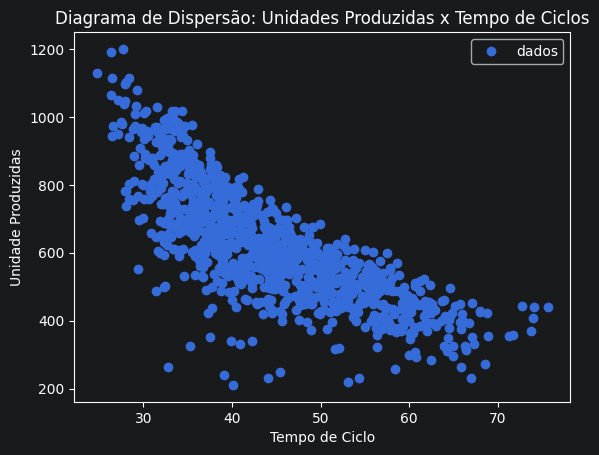

In [29]:
#Plotando o diagrama de dispersão de x por y.
plt.plot(x, y, 'o',label="dados")

#note que o nome do Diagrama é sempre y por x
plt.title('Diagrama de Dispersão: Unidades Produzidas x Tempo de Ciclos')
plt.xlabel("Tempo de Ciclo")
plt.ylabel('Unidade Produzidas')
plt.legend()
plt.show()

**Análise do diagrama de dispersão:** os pontos formam uma nuvem **descendente**: ciclos mais longos acompanham menor produção. A tendência é aproximadamente linear, embora a nuvem pareça levemente curva e mais dispersa nos ciclos curtos (abaixo de ~40 s). Isso indica relação **inversa** (negativa) e justifica medir a correlação linear.

## 3. Coeficiente de correlação de Pearson
`stats.linregress(x, y)` devolve de uma só vez os parâmetros da reta (`slope`, `intercept`), o coeficiente de correlação (`rvalue`), o p-valor e o erro padrão. Por enquanto vamos olhar o **r**, que varia de −1 a +1:
- sinal: positivo (as variáveis crescem juntas) ou negativo (uma cresce quando a outra diminui);
- módulo: quanto mais perto de 1, mais forte a relação linear. Pela convenção usual, |r| de 0,70 a 0,90 é correlação **forte**.

In [30]:
#Calculando os parâmetros da reta de regressão linear
res = stats.linregress(x, y)

#Exibindo os resultados do comando anterior.
#slope = coeficiente angular da reta de regressão linear
#intercept = coeficiente linear da reta de regressão linear
#rvalue = valor do coeficiente de correlação linear

res

LinregressResult(slope=np.float64(-13.411706202477681), intercept=np.float64(1212.194586525843), rvalue=np.float64(-0.7769597638689216), pvalue=np.float64(8.788750478431744e-203), stderr=np.float64(0.34399381730515066), intercept_stderr=np.float64(15.52358373937751))

**Interpretação da correlação:** o coeficiente de correlação de Pearson é **r ≈ −0,777**. O sinal negativo indica relação **inversa**: quando o tempo de ciclo aumenta, a quantidade produzida tende a diminuir. O módulo, 0,777, está na faixa de 0,70 a 0,90, o que, pela convenção usual, caracteriza uma correlação linear **forte**. O p-valor (≈ 8,8 × 10⁻²⁰³) é praticamente zero, então a associação não é atribuível ao acaso. Esse resultado confirma o que o diagrama de dispersão já sugeria e justifica ajustar uma reta de regressão. Correlação mede associação, não prova causalidade.

## 4. Regressão linear simples (Método dos Mínimos Quadrados)
O modelo é **ŷ = a + b · x**, em que `a` é o coeficiente linear (intercepto) e `b` o coeficiente angular (inclinação). O Método dos Mínimos Quadrados escolhe a reta que minimiza a soma dos quadrados das distâncias verticais entre os pontos e a reta. Abaixo estão o diagrama com a reta ajustada e os coeficientes obtidos.

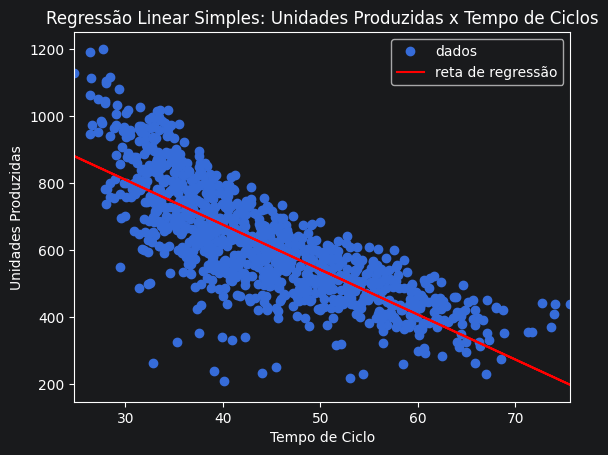

Coeficiente de correlação r = -0.7770
Coeficiente linear =  1212.1946
Coeficiente angular =  -13.4117
Reta de regressão linear y = -13.4117 *x + 1212.1946
Coeficiente de determinação r^2 = 0.6037


In [31]:
#Plotando o diagrama de dispersão de x por y e a reta de regressão linear e ajustando valores do eixo x
#Para limitar os valores do eixo x, basta usar o comando plt.xlim(Menor_valor,Maior_valor)

plt.plot(x, y, 'o', label='dados')
plt.plot(x, res.slope*x + res.intercept, 'r', label='reta de regressão')
plt.title('Regressão Linear Simples: Unidades Produzidas x Tempo de Ciclos')
plt.xlabel("Tempo de Ciclo")
plt.ylabel('Unidades Produzidas')
#cada grupo ajusta esses limites de acordo com seus dados. Use números inteiros
minimox=df.Tempo_Ciclo_s.min()
maximox=df.Tempo_Ciclo_s.max()
plt.xlim(minimox,maximox)
plt.legend()
plt.show()

#Apresentando cada coeficiente da parte de regressão linear
print(f"Coeficiente de correlação r = {res.rvalue:.4f}")
print( f"Coeficiente linear =  {res.intercept:.4f}")
print( f"Coeficiente angular =  {res.slope:.4f}")
print(f"Reta de regressão linear y = {res.slope:.4f}",f"*x + {res.intercept:.4f}" )
print(f"Coeficiente de determinação r^2 = {res.rvalue**2:.4f}")

### Interpretação da regressão
**Equação da reta:** ŷ = 1212,19 − 13,41 · x

- **Coeficiente angular (b ≈ −13,41):** a cada **1 segundo** a mais no tempo de ciclo, a produção cai, em média, cerca de **13,41 unidades**.
- **Coeficiente linear (a ≈ 1212,19):** produção prevista para x = 0. Como o menor tempo de ciclo observado é ~24,8 s, esse valor é uma extrapolação sem sentido prático e serve apenas para posicionar a reta.
- **Coeficiente de determinação (R² ≈ 0,6037):** cerca de **60,4%** da variação das unidades produzidas é explicada pelo tempo de ciclo. Os ~39,6% restantes dependem de outros fatores, entre eles, possivelmente, o nível de automação, que será investigado na tabulação cruzada.
- **Exemplos de previsão (dentro do intervalo observado, ~24,8 s a ~75,6 s):** 40 s → ≈ 676 unidades; 50 s → ≈ 542; 60 s → ≈ 408.

**Cuidado:** o ajuste é bom, mas não perfeito. Os pontos ficam acima da reta nas pontas e a dispersão é maior nos ciclos curtos, de modo que as previsões são aproximadas. Previsões fora do intervalo observado não são confiáveis.

## Conclusão e interpretação do resultado
O objetivo era verificar se o tempo de ciclo se relaciona linearmente com a produção. A análise mostrou que:
- existe **correlação linear negativa e forte** (r ≈ −0,777) entre `Tempo_Ciclo_s` e `Unidades_Produzidas`;
- a reta **ŷ = 1212,19 − 13,41 · x** indica que cada segundo adicional no ciclo reduz a produção em cerca de 13 unidades, em média;
- o tempo de ciclo explica cerca de **60,4%** da variação da produção (R² ≈ 0,6037).

Reduzir o tempo de ciclo está, portanto, associado a maior produção, o que sustenta o problema proposto. Como cerca de 40% da variação segue sem explicação, o próximo passo é investigar o papel do **nível de automação** na tabulação cruzada.